In [16]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans , DBSCAN , AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np
from gensim.models import Word2Vec


In [17]:
df1 = pd.read_csv("labeled-data.csv") 
df2 = pd.read_csv("unlabeled-data.csv")

In [18]:
print(df1.isnull().sum())
print("\n")

review_text     0
review_score    0
dtype: int64




In [19]:
print(df2.isnull().sum())
print("\n")

review_text        0
review_score    5000
dtype: int64




In [20]:
model = SentenceTransformer('all-MiniLM-L6-v2')

texts_labeled = df1['review_text'].astype(str).tolist()
texts_unlabeled = df2['review_text'].astype(str).tolist()

embeddings_labeled_ST = model.encode(texts_labeled, show_progress_bar=True)
embeddings_unlabeled_ST = model.encode(texts_unlabeled, show_progress_bar=True)

embeddings_labeled_ST_df = pd.DataFrame(embeddings_labeled_ST)
embeddings_labeled_ST_df['score'] = df1['review_score'].values

embeddings_unlabeled_ST_df = pd.DataFrame(embeddings_unlabeled_ST)

embeddings_labeled_ST_df.to_csv("labeled_embeddings_ST.csv", index=False)
embeddings_unlabeled_ST_df.to_csv("unlabeled_embeddings_ST.csv", index=False)


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [21]:
all_texts = pd.concat([df1['review_text'], df2['review_text']], ignore_index=True).astype(str)

def simple_tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())
tokenized_corpus = [simple_tokenize(text) for text in all_texts]

w2v_model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5, min_count=2, workers=4)

def sentence_embedding(text, model):
    tokens = simple_tokenize(text)
    vectors = [model.wv[word] for word in tokens if word in model.wv.key_to_index]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

embeddings_labeled_2v = np.array([sentence_embedding(text, w2v_model) for text in df1['review_text'].astype(str)])
embeddings_unlabeled_2v = np.array([sentence_embedding(text, w2v_model) for text in df2['review_text'].astype(str)])

df_emb_labeled_2v = pd.DataFrame(embeddings_labeled_2v, columns=[f'w2v_{i}' for i in range(w2v_model.vector_size)])
df_emb_labeled_2v['score'] = df1['review_score'].values

df_emb_unlabeled_2v = pd.DataFrame(embeddings_unlabeled_2v, columns=[f'w2v_{i}' for i in range(w2v_model.vector_size)])

df_emb_labeled_2v.to_csv("labeled_embeddings_W2V.csv", index=False)
df_emb_unlabeled_2v.to_csv("unlabeled_embeddings_W2V.csv", index=False)



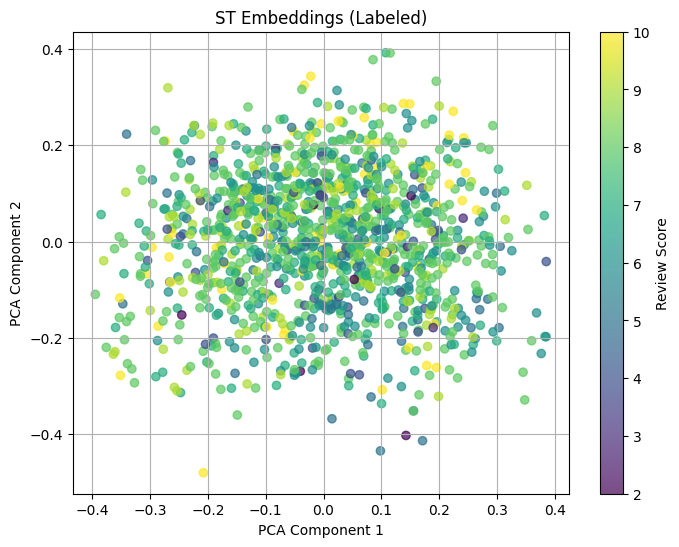

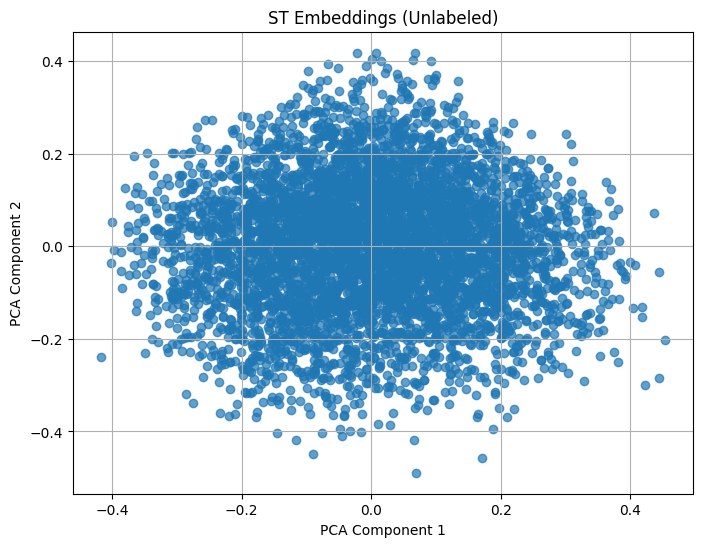

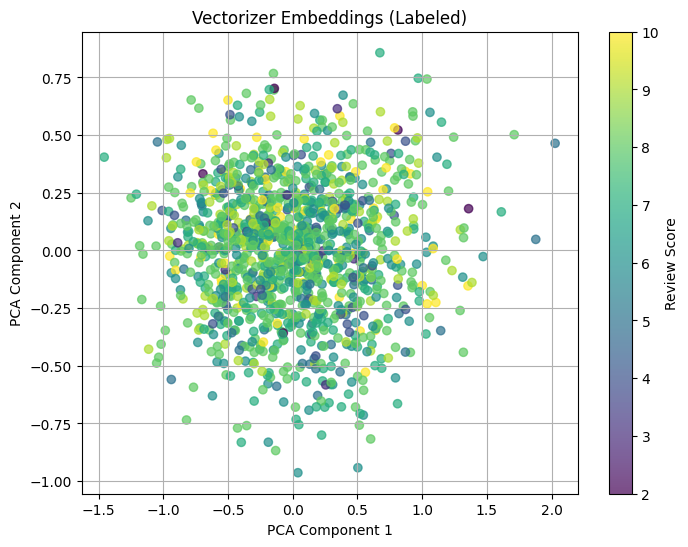

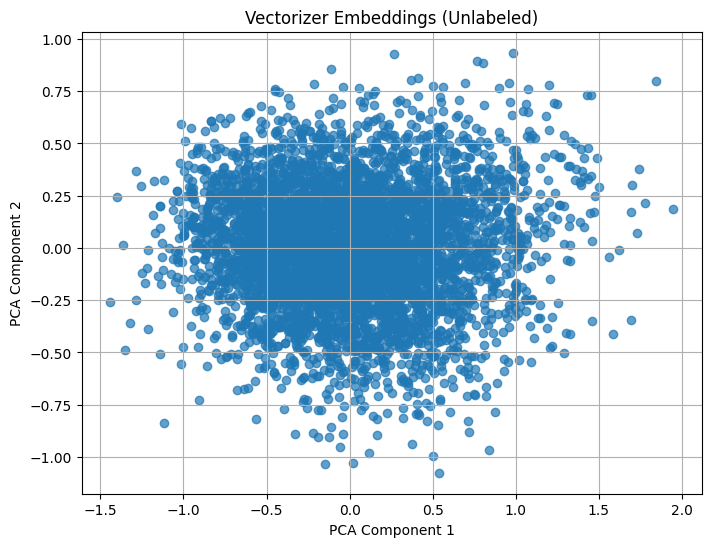

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_pca(embeddings, labels=None, title="PCA Visualization"):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)
    plt.figure(figsize=(8, 6))
    if labels is not None:
        scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='viridis', alpha=0.7)
        plt.colorbar(scatter, label='Review Score')
    else:
        plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.7)

    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(True)
    plt.show()

plot_pca(embeddings_labeled_ST, df1['review_score'].values, "ST Embeddings (Labeled)")

plot_pca(embeddings_unlabeled_ST, None, "ST Embeddings (Unlabeled)")
plot_pca(embeddings_labeled_2v, df1['review_score'].values, "Vectorizer Embeddings (Labeled)")

plot_pca(embeddings_unlabeled_2v, None, "Vectorizer Embeddings (Unlabeled)")


In [40]:
df_st = pd.read_csv("labeled_embeddings_ST.csv")
df_w2v = pd.read_csv("labeled_embeddings_W2V.csv")

print(df_st['score'].value_counts().sort_index())


score
2       6
3      12
4      52
5      66
6     188
7     241
8     452
9     162
10     71
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_classification(df, model, name="Classification Model", min_samples=10):
    print(f"\nEvaluating Classification: {name}")
    
    class_counts = df['score'].value_counts()
    valid_classes = class_counts[class_counts >= min_samples].index
    df = df[df['score'].isin(valid_classes)].copy()

    X = df.drop('score', axis=1).values
    y = df['score'].values

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print("Classification Metrics:")
    print(f"Accuracy  : {acc:.3f}")
    print(f"Precision : {prec:.3f}")
    print(f"Recall    : {rec:.3f}")
    print(f"F1-Score  : {f1:.3f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_regression(df, model, name="Regression Model", min_samples=10):
    print(f"\nEvaluating Regression: {name}")
    
    class_counts = df['score'].value_counts()
    valid_classes = class_counts[class_counts >= min_samples].index
    df = df[df['score'].isin(valid_classes)].copy()

    X = df.drop('score', axis=1).values
    y = df['score'].values

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("Regression Metrics:")
    print(f"MAE  (Mean Absolute Error)        : {mae:.3f}")
    print(f"MSE  (Mean Squared Error)         : {mse:.3f}")
    print(f"RMSE (Root Mean Squared Error)    : {rmse:.3f}")
    print(f"R²   (Coefficient of Determination): {r2:.3f}")


In [42]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR

In [43]:
evaluate_classification(df_st, LogisticRegression(max_iter=1000), "ST + Logistic Regression")
evaluate_classification(df_st, RandomForestClassifier(), "ST + Random Forest Classifier")
evaluate_classification(df_st, SVC(), "ST + Support Vector Classifier")

evaluate_regression(df_st, LinearRegression(), "ST + Linear Regression")
evaluate_regression(df_st, RandomForestRegressor(), "ST + Random Forest Regressor")
evaluate_regression(df_st, SVR(), "ST + Support Vector Regressor")



Evaluating Classification: ST + Logistic Regression
📊 Classification Metrics:
Accuracy  : 0.368
Precision : 0.175
Recall    : 0.148
F1-Score  : 0.127

Confusion Matrix:
[[ 0  0  0  0  0  1  0  0]
 [ 0  0  0  1  0  3  1  0]
 [ 0  0  0  1  1  4  0  0]
 [ 0  0  0  3  3 13  0  0]
 [ 0  0  0  1  1 22  0  0]
 [ 0  0  0  1  5 40  0  0]
 [ 0  0  0  0  2 13  2  0]
 [ 0  0  0  0  1  5  1  0]]

Detailed Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.00      0.00      0.00         6
           6       0.43      0.16      0.23        19
           7       0.08      0.04      0.05        24
           8       0.40      0.87      0.54        46
           9       0.50      0.12      0.19        17
          10       0.00      0.00      0.00         7

    accuracy                           0.37       125
   macro avg       0.18      0.15     

In [44]:
evaluate_classification(df_w2v, LogisticRegression(max_iter=1000), "W2V + Logistic Regression")
evaluate_classification(df_w2v, RandomForestClassifier(), "W2V + Random Forest Classifier")
evaluate_classification(df_w2v, SVC(), "W2V + Support Vector Classifier")

evaluate_regression(df_w2v, LinearRegression(), "W2V + Linear Regression")
evaluate_regression(df_w2v, RandomForestRegressor(), "W2V + Random Forest Regressor")
evaluate_regression(df_w2v, SVR(), "W2V + Support Vector Regressor")



Evaluating Classification: W2V + Logistic Regression
📊 Classification Metrics:
Accuracy  : 0.368
Precision : 0.140
Recall    : 0.131
F1-Score  : 0.088

Confusion Matrix:
[[ 0  0  0  0  0  1  0  0]
 [ 0  0  0  1  0  4  0  0]
 [ 0  0  0  0  0  6  0  0]
 [ 0  0  0  1  1 17  0  0]
 [ 0  0  0  0  1 22  1  0]
 [ 0  0  0  0  2 44  0  0]
 [ 0  0  0  0  0 17  0  0]
 [ 0  0  0  0  0  7  0  0]]

Detailed Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.00      0.00      0.00         6
           6       0.50      0.05      0.10        19
           7       0.25      0.04      0.07        24
           8       0.37      0.96      0.54        46
           9       0.00      0.00      0.00        17
          10       0.00      0.00      0.00         7

    accuracy                           0.37       125
   macro avg       0.14      0.13    


## **<span style="color: #8A2BE2;">Semi-Supervised Learning (SSL) Strategies</span>**

### **<span style="color: #0D6EFD;">Pseudo-Labeling</span>**

#### **<span style="color: #00FFFF;">Classifcation</span>**

In [162]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier

df_st_label = pd.read_csv("labeled_embeddings_ST.csv")
df_st_unlabel = pd.read_csv("unlabeled_embeddings_ST.csv")

class_counts = df_st_label['score'].value_counts()
valid_classes = class_counts[class_counts >= 10].index
df_st_label = df_st_label[df_st_label['score'].isin(valid_classes)].copy()

label_to_id = {label: idx for idx, label in enumerate(sorted(valid_classes))}
id_to_label = {v: k for k, v in label_to_id.items()}
df_st_label['label_id'] = df_st_label['score'].map(label_to_id)

X = df_st_label.drop(['score', 'label_id'], axis=1).values
y = df_st_label['label_id'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_unlabeled_all = df_st_unlabel.values
remaining_unlabeled = X_unlabeled_all.copy()

num_iterations = 10
top_percent = 0.01

pseudo_logs = []
metrics_logs = []

classes = sorted(np.unique(y_train))  # کلاس‌های موجود

for iteration in range(1, num_iterations + 1):
    print(f"\n🔁 Iteration {iteration}")

    model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, eval_metric='mlogloss', random_state=42)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # محاسبه AUC چندکلاسه
    y_test_bin = label_binarize(y_test, classes=classes)
    y_score = model.predict_proba(X_test)
    try:
        auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
    except Exception as e:
        print(f"Warning: Could not compute AUC at iteration {iteration}: {e}")
        auc = np.nan

    print(f"✅ Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")
    metrics_logs.append({
        'iteration': iteration,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'AUC': auc
    })

    if len(remaining_unlabeled) == 0:
        print("No more unlabeled samples.")
        break

    probs = model.predict_proba(remaining_unlabeled)
    confidences = np.max(probs, axis=1)
    num_to_add = max(1, int(top_percent * len(remaining_unlabeled)))
    top_idx = np.argsort(confidences)[-num_to_add:]

    pseudo_X = remaining_unlabeled[top_idx]
    pseudo_y = np.argmax(probs[top_idx], axis=1)

    pseudo_df = pd.DataFrame(pseudo_X)
    pseudo_df['score'] = [id_to_label[pid] for pid in pseudo_y]
    pseudo_df['label_id'] = pseudo_y
    pseudo_df['iteration'] = iteration

    pseudo_logs.append(pseudo_df)

    X_train = np.vstack([X_train, pseudo_X])
    y_train = np.concatenate([y_train, pseudo_y])

    remaining_unlabeled = np.delete(remaining_unlabeled, top_idx, axis=0)
    print(f"➕ Added {len(pseudo_X)} pseudo-labeled samples. Remaining: {len(remaining_unlabeled)}")

pd.concat(pseudo_logs, ignore_index=True).to_csv("pseudo_labels_XGB.csv", index=False)
pd.DataFrame(metrics_logs).to_csv("metrics_XGB.csv", index=False)



🔁 Iteration 1
✅ Accuracy: 0.337 | Precision: 0.249 | Recall: 0.142 | F1: 0.127 | AUC: 0.655
➕ Added 50 pseudo-labeled samples. Remaining: 4950

🔁 Iteration 2
✅ Accuracy: 0.333 | Precision: 0.230 | Recall: 0.135 | F1: 0.113 | AUC: 0.642
➕ Added 49 pseudo-labeled samples. Remaining: 4901

🔁 Iteration 3
✅ Accuracy: 0.337 | Precision: 0.192 | Recall: 0.141 | F1: 0.126 | AUC: 0.667
➕ Added 49 pseudo-labeled samples. Remaining: 4852

🔁 Iteration 4
✅ Accuracy: 0.341 | Precision: 0.163 | Recall: 0.136 | F1: 0.113 | AUC: 0.644
➕ Added 48 pseudo-labeled samples. Remaining: 4804

🔁 Iteration 5
✅ Accuracy: 0.373 | Precision: 0.276 | Recall: 0.156 | F1: 0.139 | AUC: 0.643
➕ Added 48 pseudo-labeled samples. Remaining: 4756

🔁 Iteration 6
✅ Accuracy: 0.369 | Precision: 0.201 | Recall: 0.153 | F1: 0.134 | AUC: 0.647
➕ Added 47 pseudo-labeled samples. Remaining: 4709

🔁 Iteration 7
✅ Accuracy: 0.349 | Precision: 0.197 | Recall: 0.149 | F1: 0.134 | AUC: 0.650
➕ Added 47 pseudo-labeled samples. Remainin

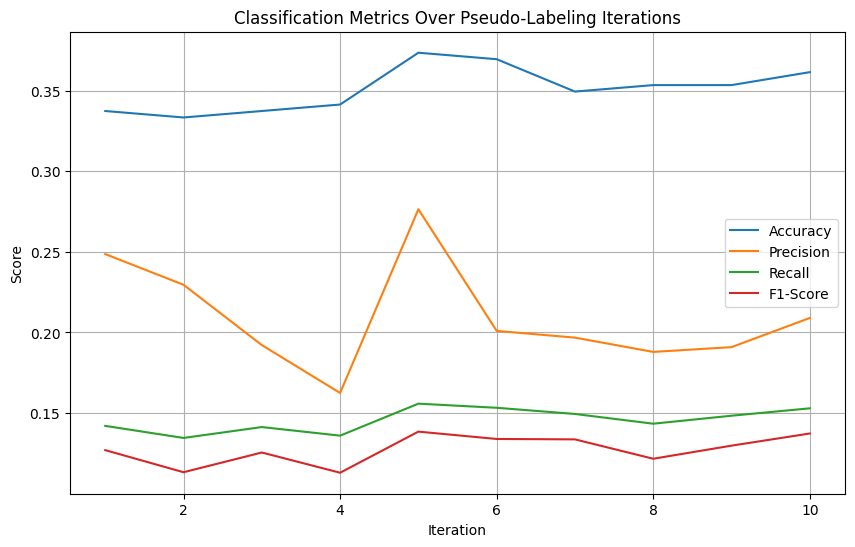

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
metrics_df = pd.read_csv("metrics_XGB.csv")

plt.figure(figsize=(10,6))
plt.plot(metrics_df['iteration'], metrics_df['accuracy'], label='Accuracy')
plt.plot(metrics_df['iteration'], metrics_df['precision'], label='Precision')
plt.plot(metrics_df['iteration'], metrics_df['recall'], label='Recall')
plt.plot(metrics_df['iteration'], metrics_df['f1_score'], label='F1-Score')

plt.xlabel("Iteration")
plt.ylabel("Score")
plt.title("Classification Metrics Over Pseudo-Labeling Iterations")
plt.legend()
plt.grid(True)
plt.show()


#### **<span style="color: #00FFFF;">Regression</span>**

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

df_label = pd.read_csv("labeled_embeddings_ST.csv")
df_unlabel = pd.read_csv("unlabeled_embeddings_ST.csv")

valid = df_label['score'].value_counts()
valid = valid[valid >= 10].index
df_label = df_label[df_label['score'].isin(valid)].copy()

X = df_label.drop('score', axis=1).values
y = df_label['score'].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_unlabeled_all = df_unlabel.values
remaining_indices = np.arange(len(X_unlabeled_all))

iteration_logs = []
metrics = []

num_iterations = 6
top_percent = 0.01

for i in range(1, num_iterations + 1):
    print(f"\n🔁 Iteration {i}")
    model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"✅ RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")

    metrics.append({'iteration': i, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

    if len(remaining_indices) == 0:
        print("✅ All unlabeled samples used.")
        break
    preds = model.predict(X_unlabeled_all[remaining_indices])
    confidence_scores = np.abs(preds - np.mean(preds))
    num_to_add = max(1, int(top_percent * len(preds)))
    top_idx = np.argsort(confidence_scores)[-num_to_add:]

    selected_indices = remaining_indices[top_idx]
    selected_X = X_unlabeled_all[selected_indices]
    selected_y = preds[top_idx]
    X_train = np.vstack([X_train, selected_X])
    y_train = np.concatenate([y_train, selected_y])

    df_pseudo = pd.DataFrame(selected_X)
    df_pseudo['pseudo_score'] = selected_y
    df_pseudo['iteration'] = i
    iteration_logs.append(df_pseudo)

    remaining_indices = np.setdiff1d(remaining_indices, selected_indices)

    print(f"➕ Added {len(selected_X)} pseudo-labeled samples. Remaining unlabeled: {len(remaining_indices)}")

pd.concat(iteration_logs, ignore_index=True).to_csv("pseudo_labels_regression.csv", index=False)
pd.DataFrame(metrics).to_csv("metrics_regression.csv", index=False)


🔁 Iteration 1
✅ RMSE: 1.372 | MAE: 1.057 | R²: 0.106
➕ Added 50 pseudo-labeled samples. Remaining unlabeled: 4950

🔁 Iteration 2
✅ RMSE: 1.335 | MAE: 1.053 | R²: 0.154
➕ Added 49 pseudo-labeled samples. Remaining unlabeled: 4901

🔁 Iteration 3
✅ RMSE: 1.361 | MAE: 1.031 | R²: 0.121
➕ Added 49 pseudo-labeled samples. Remaining unlabeled: 4852

🔁 Iteration 4
✅ RMSE: 1.342 | MAE: 1.037 | R²: 0.145
➕ Added 48 pseudo-labeled samples. Remaining unlabeled: 4804

🔁 Iteration 5
✅ RMSE: 1.356 | MAE: 1.067 | R²: 0.127
➕ Added 48 pseudo-labeled samples. Remaining unlabeled: 4756

🔁 Iteration 6
✅ RMSE: 1.277 | MAE: 0.978 | R²: 0.226
➕ Added 47 pseudo-labeled samples. Remaining unlabeled: 4709


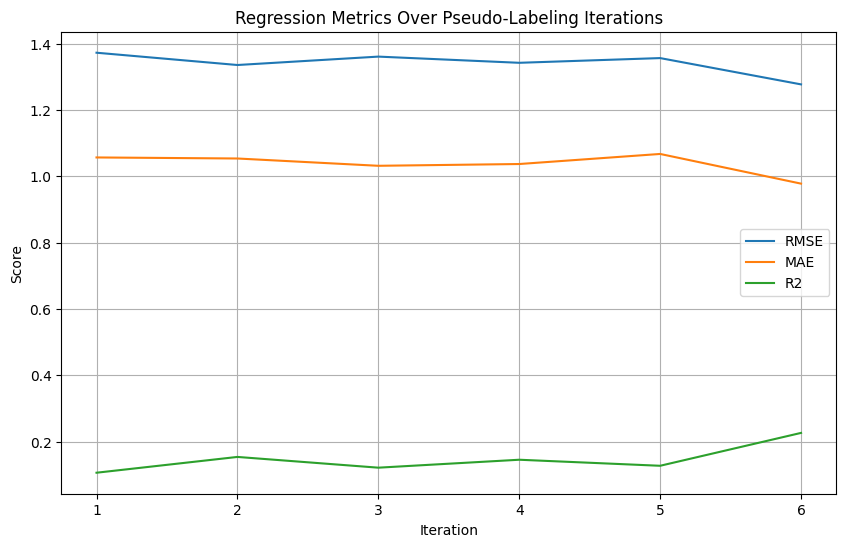

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.read_csv("metrics_regression.csv")

plt.figure(figsize=(10,6))
plt.plot(metrics_df['iteration'], metrics_df['RMSE'], label='RMSE')
plt.plot(metrics_df['iteration'], metrics_df['MAE'], label='MAE')
plt.plot(metrics_df['iteration'], metrics_df['R2'], label='R2')

plt.xlabel("Iteration")
plt.ylabel("Score")
plt.title("Regression Metrics Over Pseudo-Labeling Iterations")
plt.legend()
plt.grid(True)
plt.show()


### **<span style="color: #0D6EFD;">Active Learning</span>**

#### **<span style="color: #00FFFF;">Classifcation</span>**

In [166]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

def active_learning_run(strategy="margin", k=50, rounds=10):
    print(f"\n🧠 Starting Active Learning with strategy: {strategy.upper()}")

    df_labeled = pd.read_csv("labeled_embeddings_ST.csv")
    df_unlabeled = pd.read_csv("unlabeled_embeddings_ST.csv")

    valid_classes = df_labeled['score'].value_counts()
    valid_classes = valid_classes[valid_classes >= 10].index
    df_labeled = df_labeled[df_labeled['score'].isin(valid_classes)]

    label_to_id = {label: i for i, label in enumerate(sorted(valid_classes))}
    id_to_label = {i: label for label, i in label_to_id.items()}
    df_labeled["label_id"] = df_labeled["score"].map(label_to_id)

    X = df_labeled.drop(columns=["score", "label_id"]).values
    y = df_labeled["label_id"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
    X_pool = df_unlabeled.values

    classes = sorted(np.unique(y_train))
    performance = []
    model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                          eval_metric='mlogloss', verbosity=0, random_state=42)

    for r in range(rounds):
        print(f"\n🔁 Round {r+1}")
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')

        # محاسبه AUC
        y_test_bin = label_binarize(y_test, classes=classes)
        y_score = model.predict_proba(X_test)
        try:
            auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
        except Exception as e:
            print(f"⚠️ Warning: Could not compute AUC at round {r+1}: {e}")
            auc = np.nan

        performance.append((len(y_train), acc, f1, auc))
        print(f"✅ Train size: {len(y_train)}, Accuracy: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")

        if len(X_pool) < k:
            print("🚨 Not enough samples in pool.")
            break

        probs = model.predict_proba(X_pool)

        if strategy == "entropy":
            scores = -np.sum(probs * np.log(probs + 1e-10), axis=1)
            selected_indices = np.argsort(scores)[-k:]
        elif strategy == "margin":
            part = np.partition(-probs, 1, axis=1)
            top1 = -part[:, 0]
            top2 = -part[:, 1]
            scores = top1 - top2
            selected_indices = np.argsort(scores)[:k]
        elif strategy == "least_confidence":
            scores = 1 - np.max(probs, axis=1)
            selected_indices = np.argsort(scores)[-k:]
        else:
            raise ValueError("❌ Unknown strategy.")

        y_selected = np.argmax(probs[selected_indices], axis=1)

        X_train = np.vstack((X_train, X_pool[selected_indices]))
        y_train = np.concatenate((y_train, y_selected))

        mask = np.ones(len(X_pool), dtype=bool)
        mask[selected_indices] = False
        X_pool = X_pool[mask]

    sizes, accs, f1s, aucs = zip(*performance)
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, accs, label='Accuracy', marker='o')
    plt.plot(sizes, f1s, label='F1 Score', marker='x')
    plt.plot(sizes, aucs, label='AUC', marker='s')
    plt.xlabel("Train Set Size")
    plt.ylabel("Score")
    plt.title(f"Active Learning - {strategy.upper()} Strategy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return performance


In [167]:
import csv
def save_performance(performance, filename="active_learning_metrics_classification.csv"):
    keys = ['train_size', 'accuracy', 'f1_score', 'auc']
    with open(filename, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        for t_size, acc, f1, auc in performance:
            writer.writerow({'train_size': t_size, 'accuracy': acc, 'f1_score': f1, 'auc': auc})



🧠 Starting Active Learning with strategy: ENTROPY

🔁 Round 1
✅ Train size: 995, Accuracy: 0.337, F1: 0.127, AUC: 0.655

🔁 Round 2
✅ Train size: 1045, Accuracy: 0.345, F1: 0.127, AUC: 0.639

🔁 Round 3
✅ Train size: 1095, Accuracy: 0.333, F1: 0.120, AUC: 0.621

🔁 Round 4
✅ Train size: 1145, Accuracy: 0.365, F1: 0.136, AUC: 0.619

🔁 Round 5
✅ Train size: 1195, Accuracy: 0.337, F1: 0.111, AUC: 0.616

🔁 Round 6
✅ Train size: 1245, Accuracy: 0.353, F1: 0.102, AUC: 0.616

🔁 Round 7
✅ Train size: 1295, Accuracy: 0.337, F1: 0.074, AUC: 0.597

🔁 Round 8
✅ Train size: 1345, Accuracy: 0.386, F1: 0.124, AUC: 0.607

🔁 Round 9
✅ Train size: 1395, Accuracy: 0.341, F1: 0.071, AUC: 0.623

🔁 Round 10
✅ Train size: 1445, Accuracy: 0.345, F1: 0.078, AUC: 0.638


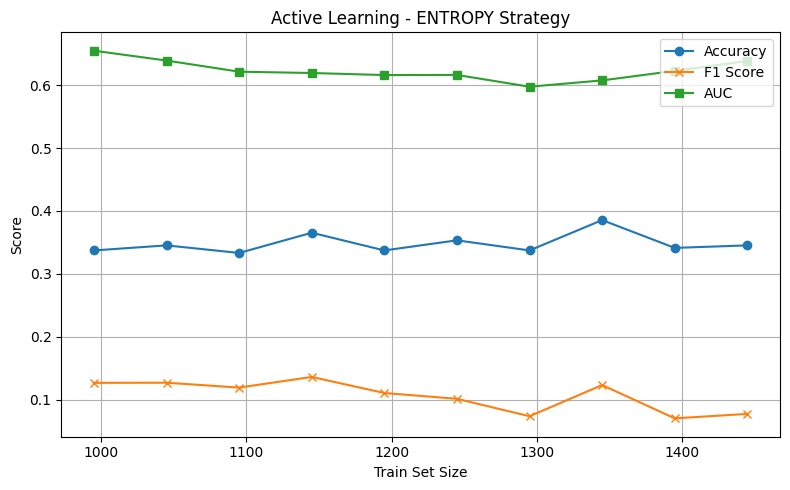

In [168]:
entropy_perf = active_learning_run(strategy="entropy")
save_performance(entropy_perf, "active_learning_entropy_metrics.csv")



🧠 Starting Active Learning with strategy: MARGIN

🔁 Round 1
✅ Train size: 995, Accuracy: 0.337, F1: 0.127, AUC: 0.655

🔁 Round 2
✅ Train size: 1045, Accuracy: 0.337, F1: 0.126, AUC: 0.647

🔁 Round 3
✅ Train size: 1095, Accuracy: 0.345, F1: 0.134, AUC: 0.637

🔁 Round 4
✅ Train size: 1145, Accuracy: 0.341, F1: 0.139, AUC: 0.649

🔁 Round 5
✅ Train size: 1195, Accuracy: 0.333, F1: 0.123, AUC: 0.660

🔁 Round 6
✅ Train size: 1245, Accuracy: 0.337, F1: 0.124, AUC: 0.667

🔁 Round 7
✅ Train size: 1295, Accuracy: 0.353, F1: 0.144, AUC: 0.654

🔁 Round 8
✅ Train size: 1345, Accuracy: 0.353, F1: 0.116, AUC: 0.672

🔁 Round 9
✅ Train size: 1395, Accuracy: 0.349, F1: 0.145, AUC: 0.662

🔁 Round 10
✅ Train size: 1445, Accuracy: 0.353, F1: 0.122, AUC: 0.685


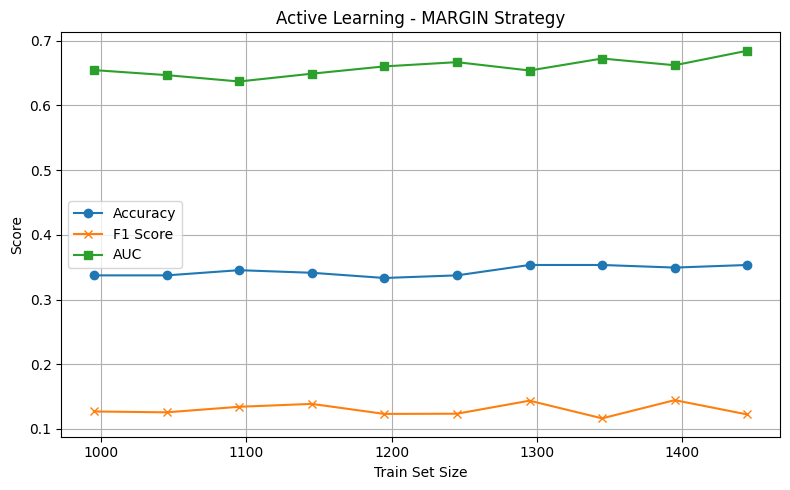

In [169]:
margin_perf = active_learning_run(strategy="margin")
save_performance(margin_perf, "active_learning_margin_metrics.csv")


🧠 Starting Active Learning with strategy: LEAST_CONFIDENCE

🔁 Round 1
✅ Train size: 995, Accuracy: 0.337, F1: 0.127, AUC: 0.655

🔁 Round 2
✅ Train size: 1045, Accuracy: 0.345, F1: 0.129, AUC: 0.647

🔁 Round 3
✅ Train size: 1095, Accuracy: 0.369, F1: 0.135, AUC: 0.667

🔁 Round 4
✅ Train size: 1145, Accuracy: 0.365, F1: 0.129, AUC: 0.645

🔁 Round 5
✅ Train size: 1195, Accuracy: 0.333, F1: 0.119, AUC: 0.643

🔁 Round 6
✅ Train size: 1245, Accuracy: 0.365, F1: 0.116, AUC: 0.638

🔁 Round 7
✅ Train size: 1295, Accuracy: 0.369, F1: 0.128, AUC: 0.647

🔁 Round 8
✅ Train size: 1345, Accuracy: 0.365, F1: 0.131, AUC: 0.635

🔁 Round 9
✅ Train size: 1395, Accuracy: 0.398, F1: 0.136, AUC: 0.649

🔁 Round 10
✅ Train size: 1445, Accuracy: 0.386, F1: 0.143, AUC: 0.652


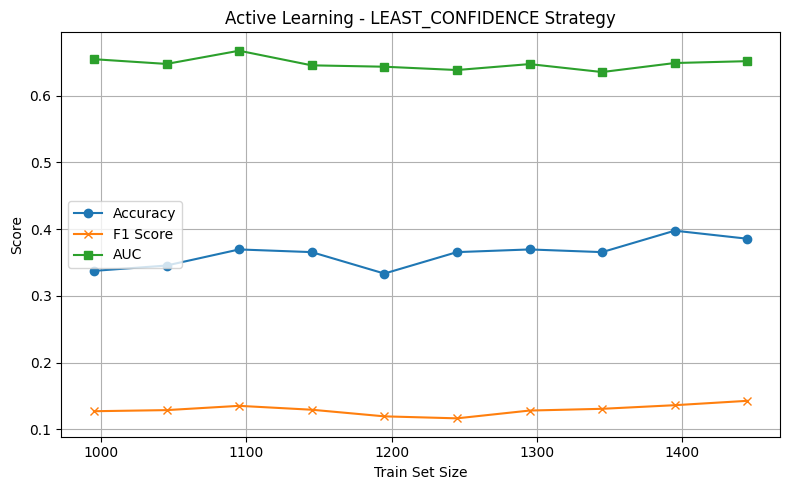

In [170]:
least_conf_perf = active_learning_run(strategy="least_confidence")
save_performance(least_conf_perf, "active_learning_least_conf_metrics.csv")

#### **<span style="color: #00FFFF;">Regression</span>**


🔁 Round 1
✅ Train size: 995, RMSE: 1.341, MAE: 1.042, R²: 0.217

🔁 Round 2
✅ Train size: 1045, RMSE: 1.339, MAE: 1.043, R²: 0.220

🔁 Round 3
✅ Train size: 1095, RMSE: 1.329, MAE: 1.033, R²: 0.232

🔁 Round 4
✅ Train size: 1145, RMSE: 1.301, MAE: 1.013, R²: 0.263

🔁 Round 5
✅ Train size: 1195, RMSE: 1.365, MAE: 1.076, R²: 0.190

🔁 Round 6
✅ Train size: 1245, RMSE: 1.334, MAE: 1.042, R²: 0.226

🔁 Round 7
✅ Train size: 1295, RMSE: 1.336, MAE: 1.045, R²: 0.223

🔁 Round 8
✅ Train size: 1345, RMSE: 1.341, MAE: 1.041, R²: 0.218

🔁 Round 9
✅ Train size: 1395, RMSE: 1.332, MAE: 1.044, R²: 0.228

🔁 Round 10
✅ Train size: 1445, RMSE: 1.320, MAE: 1.030, R²: 0.242


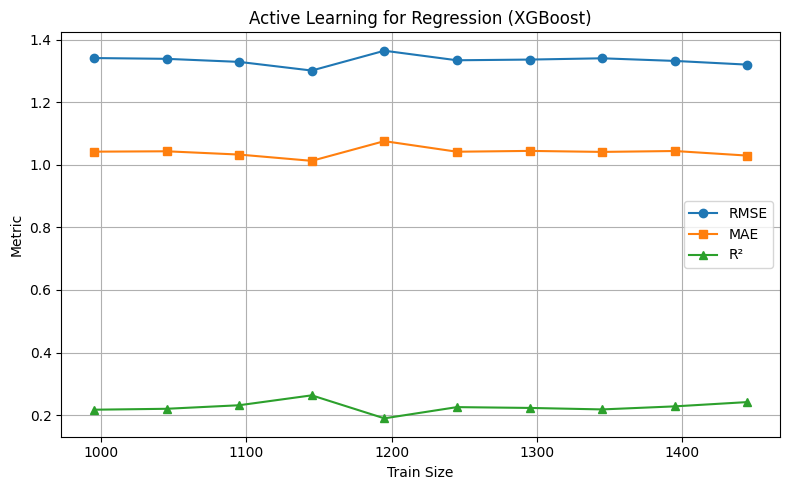

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

NUM_ITER = 10
TOP_K = 50

df_label = pd.read_csv("labeled_embeddings_ST.csv")
df_unlabel = pd.read_csv("unlabeled_embeddings_ST.csv")

valid_scores = df_label["score"].value_counts()
valid_scores = valid_scores[valid_scores >= 10].index
df_label = df_label[df_label["score"].isin(valid_scores)]

X_labeled = df_label.drop(columns=["score"]).values
y_labeled = df_label["score"].values
X_unlabeled = df_unlabel.values

X_train_orig, X_val, y_train_orig, y_val = train_test_split(X_labeled, y_labeled, test_size=0.2, random_state=42)

X_train = X_train_orig.copy()
y_train = y_train_orig.copy()
X_pool = X_unlabeled.copy()

history = []

for i in range(NUM_ITER):
    print(f"\n🔁 Round {i+1}")

    model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    print(f"✅ Train size: {len(y_train)}, RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")
    history.append([len(y_train), rmse, mae, r2])

    if len(X_pool) < TOP_K:
        print("🚨 Not enough samples left in pool.")
        break

    y_pool_pred = model.predict(X_pool)

    k_neighbors = 5
    nbrs = NearestNeighbors(n_neighbors=k_neighbors + 1).fit(X_pool)
    _, indices = nbrs.kneighbors(X_pool)

    local_uncertainty = []
    for j, pred in enumerate(y_pool_pred):
        neighbor_preds = y_pool_pred[indices[j][1:]]
        local_unc = np.std(np.append(neighbor_preds, pred))
        local_uncertainty.append(local_unc)

    top_k_indices = np.argsort(local_uncertainty)[-TOP_K:]
    X_new = X_pool[top_k_indices]
    y_new = y_pool_pred[top_k_indices]

    X_train = np.vstack([X_train, X_new])
    y_train = np.concatenate([y_train, y_new])

    mask = np.ones(len(X_pool), dtype=bool)
    mask[top_k_indices] = False
    X_pool = X_pool[mask]

history = np.array(history)
plt.figure(figsize=(8,5))
plt.plot(history[:,0], history[:,1], label="RMSE", marker='o')
plt.plot(history[:,0], history[:,2], label="MAE", marker='s')
plt.plot(history[:,0], history[:,3], label="R²", marker='^')
plt.xlabel("Train Size")
plt.ylabel("Metric")
plt.title("Active Learning for Regression (XGBoost)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(history, columns=["Train_Size", "RMSE", "MAE", "R2"]).to_csv("regression_active_learning_metrics.csv", index=False)


## **<span style="color: #8A2BE2;">Evaluation</span>**

#### **<span style="color: #00ff44ff;">Summary of Metrics</span>**

#### **<span style="color: #00FFFF;">Classifcation</span>**

In [ ]:
import pandas as pd

baseline_classification = pd.read_csv("metrics_XGB.csv").iloc[0].copy()
baseline_classification['method'] = "Baseline (Pseudo-labeling Start)"
baseline_classification['train_size'] = 0 

pseudo_metrics = pd.read_csv("metrics_XGB.csv")
pseudo_metrics['method'] = "Pseudo-labeling"

al_entropy = pd.read_csv("active_learning_entropy_metrics.csv")
al_entropy['method'] = "Active Learning Entropy"

al_margin = pd.read_csv("active_learning_margin_metrics.csv")
al_margin['method'] = "Active Learning Margin"

al_least_conf = pd.read_csv("active_learning_least_conf_metrics.csv")
al_least_conf['method'] = "Active Learning Least Confidence"

classification_metrics = pd.concat([
    pd.DataFrame([baseline_classification]),
    pseudo_metrics,
    al_entropy,
    al_margin,
    al_least_conf
], ignore_index=True)

print(classification_metrics[['method', 'train_size', 'accuracy', 'f1_score']])


                              method  train_size  accuracy  f1_score
0   Baseline (Pseudo-labeling Start)         0.0  0.337349  0.127044
1                    Pseudo-labeling         NaN  0.337349  0.127044
2                    Pseudo-labeling         NaN  0.333333  0.113342
3                    Pseudo-labeling         NaN  0.337349  0.125569
4                    Pseudo-labeling         NaN  0.341365  0.113035
5                    Pseudo-labeling         NaN  0.373494  0.138521
6                    Pseudo-labeling         NaN  0.369478  0.133970
7                    Pseudo-labeling         NaN  0.349398  0.133717
8                    Pseudo-labeling         NaN  0.353414  0.121702
9                    Pseudo-labeling         NaN  0.353414  0.129823
10                   Pseudo-labeling         NaN  0.361446  0.137357
11           Active Learning Entropy       995.0  0.337349  0.127044
12           Active Learning Entropy      1045.0  0.345382  0.127247
13           Active Learning Entro

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

df_label = pd.read_csv("labeled_embeddings_ST.csv")

valid_classes = df_label['score'].value_counts()
valid_classes = valid_classes[valid_classes >= 10].index
df_label = df_label[df_label['score'].isin(valid_classes)].copy()

label_to_id = {label: i for i, label in enumerate(sorted(valid_classes))}
df_label['label_id'] = df_label['score'].map(label_to_id)

X = df_label.drop(columns=['score', 'label_id']).values
y = df_label['label_id'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,  eval_metric='mlogloss', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("Baseline Classification")
print(f"Train size: {len(y_train)}")
print(f"Accuracy: {acc:.3f}")
print(f"F1 Score: {f1:.3f}")


Baseline Classification
Train size: 995
Accuracy: 0.337
F1 Score: 0.127


#### **<span style="color: #00FFFF;">Regression</span>**

In [ ]:
baseline_regression = pd.read_csv("metrics_regression.csv").iloc[0].copy()
baseline_regression['method'] = "Baseline (Pseudo-labeling Start)"
baseline_regression['train_size'] = 0

pseudo_regression = pd.read_csv("metrics_regression.csv")
pseudo_regression['method'] = "Pseudo-labeling"

al_regression = pd.read_csv("regression_active_learning_metrics.csv")
al_regression['method'] = "Active Learning Regression"

regression_metrics = pd.concat([
    pd.DataFrame([baseline_regression]),
    pseudo_regression,
    al_regression
], ignore_index=True)

print(regression_metrics[['method', 'train_size', 'RMSE', 'MAE', 'R2']])


                              method  train_size      RMSE       MAE        R2
0   Baseline (Pseudo-labeling Start)         0.0  1.372302  1.056561  0.106052
1                    Pseudo-labeling         NaN  1.372302  1.056561  0.106052
2                    Pseudo-labeling         NaN  1.335259  1.053404  0.153662
3                    Pseudo-labeling         NaN  1.360579  1.031416  0.121260
4                    Pseudo-labeling         NaN  1.341924  1.036752  0.145192
5                    Pseudo-labeling         NaN  1.356133  1.067096  0.126993
6                    Pseudo-labeling         NaN  1.276830  0.977595  0.226110
7         Active Learning Regression         NaN  1.341361  1.042102  0.217299
8         Active Learning Regression         NaN  1.338826  1.043326  0.220254
9         Active Learning Regression         NaN  1.329074  1.032838  0.231572
10        Active Learning Regression         NaN  1.301395  1.012770  0.263245
11        Active Learning Regression         NaN  1.

In [ ]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

df_label = pd.read_csv("labeled_embeddings_ST.csv")

valid_scores = df_label['score'].value_counts()
valid_scores = valid_scores[valid_scores >= 10].index
df_label = df_label[df_label['score'].isin(valid_scores)].copy()

X = df_label.drop(columns=['score']).values
y = df_label['score'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Baseline Regression")
print(f"Train size: {len(y_train)}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")


Baseline Regression
Train size: 995
RMSE: 1.341
MAE: 1.042
R²: 0.217


#### **<span style="color: #00ff44ff;">ROC and AUC Curves</span>**

#### **<span style="color: #8db422ff;">ROC</span>**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc

def plot_roc_from_dataframe_filtered(df,label_column='score',title='Model ROC Curve',is_pseudo=False,feature_columns=None,min_samples_per_class=10):
    class_counts = df[label_column].value_counts()
    valid_classes = class_counts[class_counts >= min_samples_per_class].index
    df = df[df[label_column].isin(valid_classes)].copy()
    label_to_id = {label: i for i, label in enumerate(sorted(valid_classes))}
    id_to_label = {i: label for label, i in label_to_id.items()}
    df["label_id"] = df[label_column].map(label_to_id)

    if is_pseudo:
        if feature_columns is None:
            raise ValueError("You must provide 'feature_columns' when is_pseudo=True")
        X = df[feature_columns].values
    else:
        X = df.drop(columns=[label_column, "label_id"]).values

    y = df["label_id"].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        eval_metric='mlogloss',
        verbosity=0,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_score = model.predict_proba(X_test)
    y_true = y_test

    n_classes = len(np.unique(y))
    y_test_bin = label_binarize(y_true, classes=range(n_classes))
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        try:
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        except:
            fpr[i], tpr[i], roc_auc[i] = [0], [0], float('nan')

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    plt.figure(figsize=(8, 6))
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.2f})', linewidth=2)
    colors = plt.colormaps.get_cmap('tab10')
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], color=colors(i), lw=1.5,
                 label=f'Class {id_to_label[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()



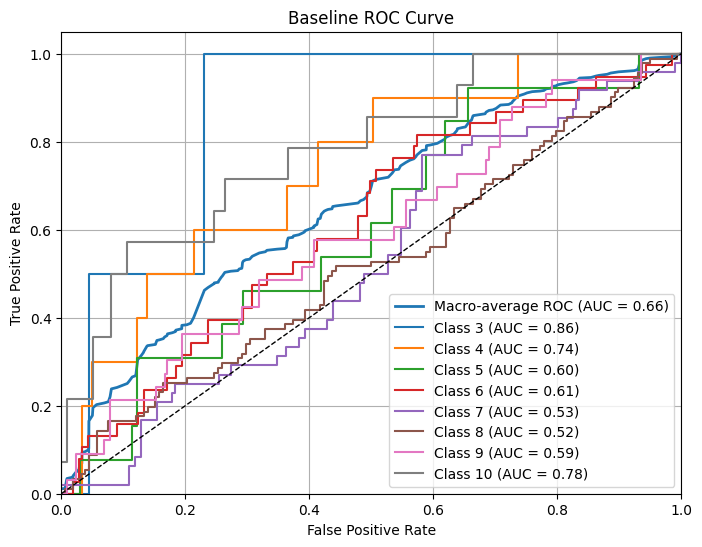

In [147]:
df_baseline = pd.read_csv("labeled_embeddings_ST.csv")
plot_roc_from_dataframe_filtered(df_baseline, label_column='score', title='Baseline ROC Curve')

#### **<span style="color: #8db422ff;">AUC</span>**

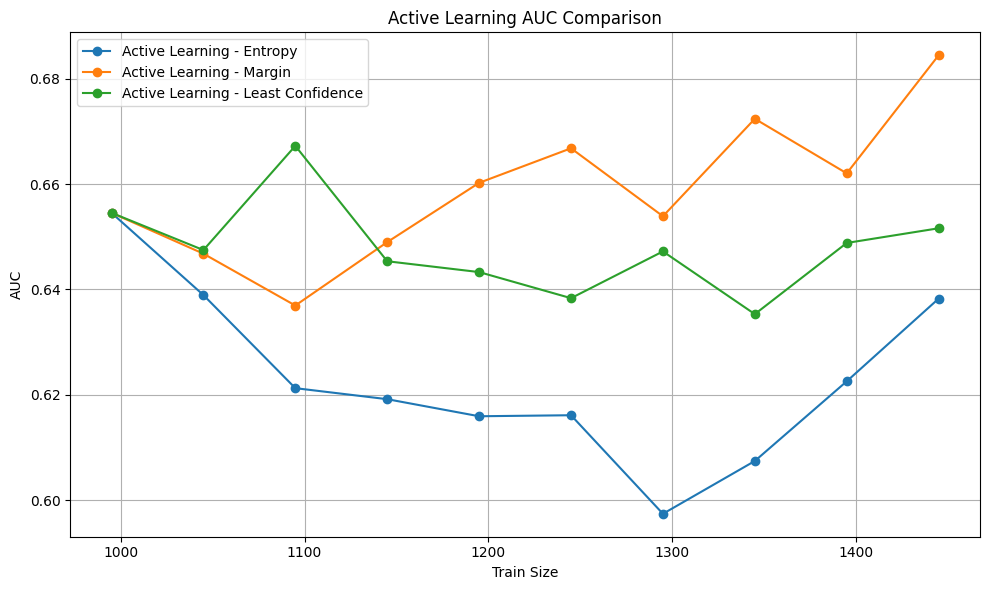

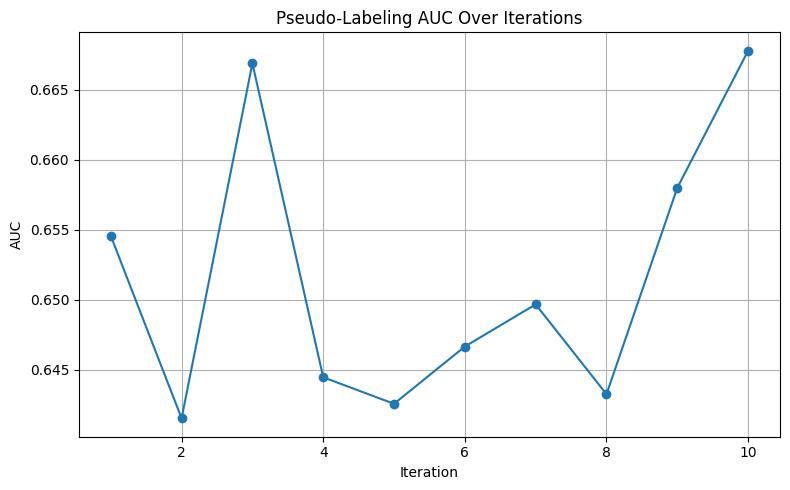

In [181]:
import pandas as pd
import matplotlib.pyplot as plt

def read_metrics(file_path, metric_name='AUC'):
    df = pd.read_csv(file_path)
    matched_cols = [col for col in df.columns if col.lower() == metric_name.lower()]
    if not matched_cols:
        raise ValueError(f"Metric '{metric_name}' not found in {file_path}. Available columns: {list(df.columns)}")
    metric_col = matched_cols[0]
    x_col = 'iteration' if 'iteration' in df.columns else 'train_size'
    return df[[x_col, metric_col]]

def plot_active_learning(active_files, metric_name='AUC'):
    plt.figure(figsize=(10, 6))
    for name, filepath in active_files.items():
        active_df = read_metrics(filepath, metric_name)
        plt.plot(active_df.iloc[:,0], active_df.iloc[:,1], marker='o', label=f'Active Learning - {name}')
    plt.title(f'Active Learning {metric_name} Comparison')
    plt.xlabel('Train Size')
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_pseudo_labeling(pseudo_file, metric_name='AUC'):
    pseudo_df = read_metrics(pseudo_file, metric_name)
    plt.figure(figsize=(8, 5))
    plt.plot(pseudo_df.iloc[:,0], pseudo_df.iloc[:,1], marker='o', color='tab:blue')
    plt.title(f'Pseudo-Labeling {metric_name} Over Iterations')
    plt.xlabel('Iteration')
    plt.ylabel(metric_name)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ====== نمونه صدا زدن =======
pseudo_file = 'metrics_XGB.csv'
active_files = {
    'Entropy': 'active_learning_entropy_metrics.csv',
    'Margin': 'active_learning_margin_metrics.csv',
    'Least Confidence': 'active_learning_least_conf_metrics.csv'
}

plot_active_learning(active_files, metric_name='AUC')
plot_pseudo_labeling(pseudo_file, metric_name='AUC')


## کدوم روش بیشترین بهبود عملکرد رو داشته ؟

مارجین متریک AUC بهتری داشته

البته که معیار های دیگری مثل دقت و اف 1 اسکور هم هستند ولی در کل اکتیو لرنینگ به نظرم بهتر از سودو لیبلینگ بود

##  تحت چه شرایطی ممکن است یکی از این دو روش بهتر باشد؟

### سودو لیبلینگ بهتر است وقتی:

داده‌های بدون برچسب بسیار مشابه داده‌های برچسب‌خورده هستند.

برچسب‌گذاری دستی هزینه‌بر یا زمان‌بر است و نمی‌خواهیم زیاد به انسان مراجعه کنیم.

مدل اولیه نسبتاً دقیق است و می‌تواند برچسب‌های خوب پیش‌بینی کند.

### یادگیری فعال بهتر است وقتی:

می‌خواهیم با کمترین تعداد نمونه‌های برچسب‌خورده بیشترین یادگیری را داشته باشیم.

داده‌های بدون برچسب بسیار متنوع یا دارای توزیع‌های متفاوت هستند.

برچسب‌گذاری دستی امکان‌پذیر است ولی می‌خواهیم هزینه آن را به حداقل برسانیم.

می‌خواهیم با انتخاب نمونه‌های "سخت" یا "مبهم" مدل را بهتر و سریع‌تر بهبود دهیم.



## مزایا و معایب هر روش، مشکلات احتمالی:

### سودو لیبیلنگ:

#### مزایا:

نیاز کمتر به برچسب‌گذاری دستی.

سریع‌تر و آسان‌تر برای پیاده‌سازی.

#### معایب:

ریسک سوگیری تأیید وقتی مدل اشتباه می‌کند و این اشتباهات به داده‌های آموزشی وارد می‌شود، مدل می‌تواند به سمت خطاها قفل شود و کیفیت آموزش افت کند.

برچسب‌های نادرست می‌توانند باعث کاهش عملکرد مدل شوند.

برای شروع نیازمند یک مدل نسبتاً دقیق اولیه است.

### یادگیری فعال:

#### مزایا:

بهبود سریع‌تر عملکرد با انتخاب داده‌های با ارزش بیشتر برای برچسب‌گذاری.

کاهش هزینه برچسب‌گذاری به خاطر محدود کردن نمونه‌های مورد نیاز.

#### معایب:

نیاز به برچسب‌گذاری دستی مکرر که ممکن است پرهزینه یا زمان‌بر باشد.

انتخاب نادرست نمونه‌ها (مثلاً نمونه‌هایی که واقعا مفید نیستند) می‌تواند کارایی را کاهش دهد.

پیچیدگی بالاتر در پیاده‌سازی و مدیریت فرآیند یادگیری.